# Example of Gain and Noise Figure Plotting and Analsysis
The purpose of this notebook is to show examples of retrieving and plotting gain and noise figure from the [NASCTN CBRS SEA data set](https://data.nist.gov/od/id/mds2-4214).

## Imports

In [1]:
from nasctn_sea_visualization import *
import pandas as pd
import numpy as np

Importing nasctn_sea_visualization.data_models
It took 1.693882 s to import nasctn_sea_visualization.data_models
Importing nasctn_sea_visualization.plotters


It took 2.689318 s to import nasctn_sea_visualization.plotters
It took 4.3832 s to import all of the active modules


In [2]:
day_block_path = "2024-07-15_GMM.zip"
day_block = DayBlock(file_path = day_block_path)

In [3]:
single = day_block.get_single(pd.to_datetime("2024-07-15 12:00",utc=True))

In [4]:
data_product = DataProduct(data = single)

In [5]:
single_plotter = DataProductPlotter(data_product)

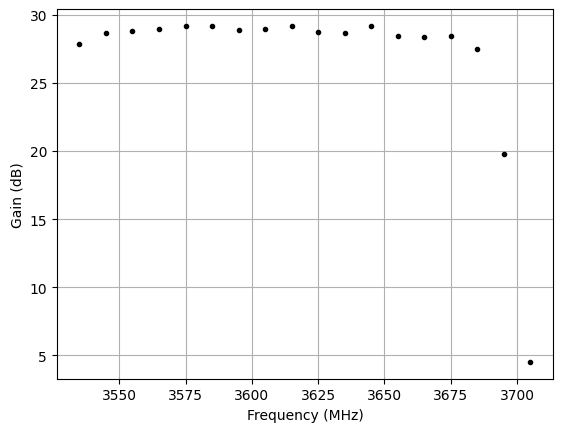

In [6]:
single_plotter.plot_gains()

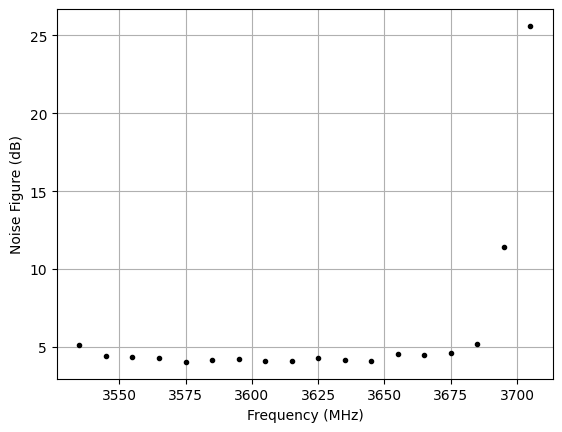

In [7]:
single_plotter.plot_noise_figures()

In [8]:
gain_daily_min = []
gain_daily_median = []
gain_daily_max = []
for frequency in day_block.frequencies:
    gain_daily_min.append(np.min(day_block.gains[frequency]))
    gain_daily_median.append(np.median(day_block.gains[frequency]))
    gain_daily_max.append(np.max(day_block.gains[frequency]))

In [9]:
noise_figure_daily_min = []
noise_figure_daily_median = []
noise_figure_daily_max = []
for frequency in day_block.frequencies:
    noise_figure_daily_min.append(np.min(day_block.noise_figures[frequency]))
    noise_figure_daily_median.append(np.median(day_block.noise_figures[frequency]))
    noise_figure_daily_max.append(np.max(day_block.noise_figures[frequency]))

In [10]:
frequencies = day_block.frequencies
frequencies = 10**-6*np.array(frequencies)

Text(0.5, 1.0, 'GMM on 2024-07-04')

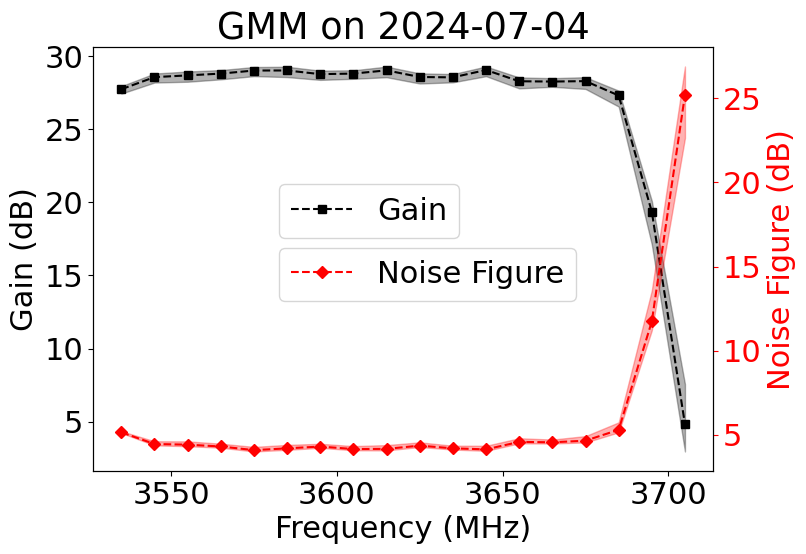

In [32]:
plt.rcParams.update({"font.size":22})
figure,ax = plt.subplots(figsize=(8,5.5))
ax.plot(frequencies,gain_daily_median,linestyle = "dashed",color = "k",marker="s",label="Gain")
ax.fill_between(x= frequencies,y1= gain_daily_min,y2 =gain_daily_max ,alpha = .3,color = "k")
twinax = ax.twinx()
twinax.plot(frequencies,noise_figure_daily_median,linestyle = "dashed",
            color = "r",marker="D",label="Noise Figure")
twinax.fill_between(x= frequencies,y1= noise_figure_daily_min,y2 =noise_figure_daily_max ,alpha = .3,color = "r")
ax.set_ylabel("Gain (dB)")
twinax.set_ylabel("Noise Figure (dB)",color='r')
twinax.legend(loc = (0.3, 0.4))
ax.legend(loc =(0.3, 0.55))
ax.set_xlabel("Frequency (MHz)")
twinax.tick_params("y",colors='r')
ax.set_title("GMM on 2024-07-04")